In [1]:
!pip install ucimlrepo
!pip install plotly



In [25]:
from ucimlrepo import fetch_ucirepo

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_predict

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score
import plotly.express as px


from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import make_scorer, f1_score
import joblib


In [3]:
# fetch dataset
statlog_german_credit_data = fetch_ucirepo(id=144)

X = statlog_german_credit_data.data.features
y = statlog_german_credit_data.data.targets

statlog_german_credit_data.metadata

statlog_german_credit_data.variables


,name,role,type,demographic,description,units,missing_values
0,Attribute1,Feature,Categorical,None,Status of existing checking account,None,no
1,Attribute2,Feature,Integer,None,Duration,months,no
2,Attribute3,Feature,Categorical,None,Credit history,None,no
3,Attribute4,Feature,Categorical,None,Purpose,None,no
4,Attribute5,Feature,Integer,None,Credit amount,None,no
5,Attribute6,Feature,Categorical,None,Savings account/bonds,None,no
6,Attribute7,Feature,Categorical,Other,Present employment since,None,no
7,Attribute8,Feature,Integer,None,Installment rate in percentage of disposable i...,None,no
8,Attribute9,Feature,Categorical,Marital Status,Personal status and sex,None,no
9,Attribute10,Feature,Categorical,None,Other debtors / guarantors,None,no


In [4]:
#checking data imbalance
y.value_counts()

,count
class,
1,700
2,300


## Data Preprocessing

- Renaming the columns
- Renaming columns categorical values
-

In [5]:
#renaming the columns
features = [
    "Status of existing checking account",       # Attribute 1
    "Duration",                                  # Attribute 2 (months)
    "Credit history",                            # Attribute 3
    "Purpose",                                   # Attribute 4
    "Credit amount",                             # Attribute 5
    "Savings account/bonds",                     # Attribute 6
    "Present employment since",                  # Attribute 7
    "Installment rate in percentage of disposable income",  # Attribute 8
    "Personal status and sex",                   # Attribute 9
    "Other debtors / guarantors",                # Attribute 10
    "Present residence since",                   # Attribute 11 (years)
    "Property",                                  # Attribute 12
    "Age",                                       # Attribute 13 (years)
    "Other installment plans",                   # Attribute 14
    "Housing",                                   # Attribute 15
    "Number of existing credits at this bank",   # Attribute 16
    "Job",                                       # Attribute 17
    "Number of people being liable to provide maintenance for", # Attribute 18
    "Telephone",                                 # Attribute 19
    "Foreign worker"                           # Attribute 20
]

codded_features = [
    "Attribute1",
    "Attribute2",
    "Attribute3",
    "Attribute4",
    "Attribute5",
    "Attribute6",
    "Attribute7",
    "Attribute8",
    "Attribute9",
    "Attribute10",
    "Attribute11",
    "Attribute12",
    "Attribute13",
    "Attribute14",
    "Attribute15",
    "Attribute16",
    "Attribute17",
    "Attribute18",
    "Attribute19",
    "Attribute20"
    ]


rename_dict = dict(zip(codded_features, features))
X = X.rename(columns=rename_dict)
X.head()

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,Present residence since,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,Foreign worker
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201


In [8]:
X_features = X.copy()

In [6]:
def map_column_values(df, column_name, mapping_dict, new_column_name):
  df[new_column_name] = df[column_name].map(mapping_dict)
  return df

In [9]:
#renaming classes values
checking_sring_map = {
    'A11': '< 0',    # < 0 DM
    'A12': '0-200',   # average of 0–200
    'A13':  '> 200',   # assume regular deposits
    'A14': 'no account'     # no account
}

credit_history_stirng_map = {
    'A30': 'no credits taken/ all credits paid back duly',
    'A31': 'all credits at this bank paid back duly',
    'A32': 'existing credits paid back duly till now',
    'A33': 'delay in paying off in the past',
    'A34': 'critical account/ other credits existing'
}

purpose_string_map = {
    'A40': 'new car',
    'A41': 'used car',
    'A42': 'furniture/equipment',
    'A43': 'radio/television',
    'A44': 'domestic appliances',
    'A45': 'repairs',
    'A46': 'education',
    'A47': 'vacation',
    'A48': 'retraining',
    'A49': 'business',
    'A410': 'others'}

savings_string_map = {
    'A61': '< 100',
    'A62': '100-500',
    'A63': '500-1000',
    'A64': '>= 1000',
    'A65': 'unknown'
}

employment_string_map = {
    'A71': 'unemployed',
    'A72': '< 1 year',
    'A73': '1-4 years',
    'A74': '4-7 years',
    'A75': '>= 7 years'
}

other_guarantors_string_map = {
    'A101': 'none',
    'A102': 'co-applicant',
    'A103': 'guarantor'
}

property_string_map = {
    'A124': 'unknown',
    'A123': 'car/other',
    'A122': 'insurance/savings',
    'A121': 'real estate'
}

other_installment_string_map = {
    'A143': 'none',
    'A142': 'stores',
    'A141': 'bank'
}

housing_map_string = {
    'A153': 'free',
    'A152': 'own',
    'A151': 'rent'
}

job_map_string = {
    'A171': 'unemployed/unskilled - non-resident',
    'A172': 'unskilled - resident',
    'A173': 'skilled employee/official',
    'A174': 'management/highly qualified employee'
}

telephone_map = {
    'A191': 0,  # no phone
    'A192': 1   # has phone
}

foreign_worker_map = {
    'A201': 1,  # foreign
    'A202': 0   # native
}

X_features = map_column_values(X_features, 'Job', job_map_string, 'job_string')
X_features = map_column_values(X_features, 'Housing', housing_map_string, 'housing_string')
X_features = map_column_values(X_features, 'Other installment plans', other_installment_string_map, 'other_installment_string')
X_features = map_column_values(X_features, 'Property', property_string_map, 'property_string')
X_features = map_column_values(X_features, 'Other debtors / guarantors', other_guarantors_string_map, 'other_guarantors_string')
X_features = map_column_values(X_features, 'Present employment since', employment_string_map, 'employment_string')
X_features = map_column_values(X_features, 'Savings account/bonds', savings_string_map, 'savings_string')
X_features = map_column_values(X_features, 'Purpose', purpose_string_map, 'purpose_string')
X_features = map_column_values(X_features, 'Status of existing checking account', checking_sring_map, 'checking_status_string')
X_features = map_column_values(X_features, 'Credit history', credit_history_stirng_map, 'credit_history_string')

#binary transformation
X_features['has_guarantor'] = X_features['Other debtors / guarantors'].apply(lambda x: 0 if x == 'A101' else 1)
X_features['is_unemployed'] = (X_features['Job'] == 'A171').astype(int)
X_features['has_telephone'] = X_features['Telephone'].map(telephone_map)
X_features['is_foreign'] = X_features['Foreign worker'].map(foreign_worker_map)
X_features['has_other_debts'] = X_features['Other installment plans'].apply(lambda x: 0 if x == 'A143' else 1) # take care from the mapping


# Display the updated DataFrame to verify
display(X_features.head())

,Status of existing checking account,Duration,Credit history,Purpose,Credit amount,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,employment_string,savings_string,purpose_string,checking_status_string,credit_history_string,has_guarantor,is_unemployed,has_telephone,is_foreign,has_other_debts
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,>= 7 years,unknown,radio/television,< 0,critical account/ other credits existing,0,0,1,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,1-4 years,< 100,radio/television,0-200,existing credits paid back duly till now,0,0,0,1,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,4-7 years,< 100,education,no account,critical account/ other credits existing,0,0,0,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,4-7 years,< 100,furniture/equipment,< 0,existing credits paid back duly till now,1,0,0,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,1-4 years,< 100,new car,< 0,delay in paying off in the past,0,0,0,1,0


In [10]:
age_bins = [0, 25, 35, 45, 60, X_features['Age'].max()]
age_labels = ['<25', '25–35', '35–45', '45–60', '60+']
X_features['AgeGroup'] = pd.cut(X_features['Age'], bins=age_bins, labels=age_labels, right=False)

In [11]:
binary_mappings = {
    'has_guarantor': {0: 'No', 1: 'Yes'},
    'is_unemployed': {0: 'No', 1: 'Yes'},
    'has_telephone': {0: 'No', 1: 'Yes'},
    'is_foreign': {0: 'No', 1: 'Yes'},
    'has_other_debts': {0: 'No', 1: 'Yes'},
}

X_features.replace(binary_mappings, inplace=True)

In [12]:
#extracting gender and martial status

def get_gender(code):
    if code in ['A91', 'A93', 'A94']:
        return 'male'
    else:
        return 'female'

def get_marital_status(code):
    if code in ['A91', 'A92']:
        return 'divorced'
    elif code in ['A93', 'A95']:
        return 'single'
    else:
        return 'married'

X_features['gender'] = X_features['Personal status and sex'].apply(get_gender)
X_features['marital_status'] = X_features['Personal status and sex'].apply(get_marital_status)

In [13]:

def plot_feature_by_agegroup(df, feature_col, age_col='AgeGroup', target_col='Creditability'):
    age_groups = df[age_col].dropna().unique()

    for group in age_groups:
        sub_df = df[df[age_col] == group]

        count_df = (
            sub_df.groupby([feature_col, target_col])
            .size()
            .reset_index(name='count')
        )
        count_df['percent'] = (
            count_df['count'] / count_df.groupby(feature_col)['count'].transform('sum') * 100
        )
        count_df[target_col] = count_df[target_col].astype(str)

        fig = px.bar(
            count_df,
            x=feature_col,
            y='count',
            color=target_col,
            barmode='group',
            hover_data=['percent'],
            title=f'{feature_col.replace("_", " ").title()} vs {target_col} – Age Group: {group}'
        )
        fig.update_layout(
            xaxis_title=feature_col.replace("_", " ").title(),
            yaxis_title='Count',
            xaxis_tickangle=-45
        )
        fig.show()


In [14]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Prepare data
df_plot = X_features.copy()
df_plot['Creditability'] = y.astype(str)
df_plot = df_plot.dropna(subset=['Creditability'])

# Replace binary 0/1 values with labels
binary_mappings = {
    'has_guarantor': {0: 'No', 1: 'Yes'},
    'is_unemployed': {0: 'No', 1: 'Yes'},
    'has_telephone': {0: 'No', 1: 'Yes'},
    'is_foreign': {0: 'No', 1: 'Yes'},
    'has_other_debts': {0: 'No', 1: 'Yes'},
}
df_plot.replace(binary_mappings, inplace=True)

# Categorical features
categorical_cols = [
    'checking_status_string',
    'credit_history_string',
    'purpose_string',
    'savings_string',
    'employment_string',
    'other_guarantors_string',
    'property_string',
    'other_installment_string',
    'housing_string',
    'job_string',
    'gender',
    'marital_status',
    'has_guarantor',
    'is_unemployed',
    'has_telephone',
    'is_foreign',
    'has_other_debts'
]

color_map = {'1': '#2ca02c', '2': '#d62728'}

for col in categorical_cols:
    # Count
    count_df = df_plot.groupby([col, 'Creditability']).size().reset_index(name='count')
    count_df['Creditability'] = count_df['Creditability'].astype(str)

    # Percentage heatmap
    heat_df = df_plot.groupby([col, 'Creditability']).size().unstack(fill_value=0)
    heat_df_percent = heat_df.div(heat_df.sum(axis=1), axis=0) * 100
    heat_df_percent = heat_df_percent.sort_index()

    fig = make_subplots(
        rows=2, cols=1,
        shared_xaxes=False,
        vertical_spacing=0.1,
        subplot_titles=(
            f"Count and Perccentage of Creditability by {col.replace('_', ' ').title()}"      , '   ' ),
        specs=[[{"type": "xy"}], [{"type": "heatmap"}]]
    )

    # Bar plot
    for credit_label in count_df['Creditability'].unique():
        sub_df = count_df[count_df['Creditability'] == credit_label]
        fig.add_trace(
            go.Bar(
                x=sub_df[col],
                y=sub_df['count'],
                name=f"{credit_label} (count)",
                marker_color=color_map.get(credit_label),
                showlegend=(col == categorical_cols[0]),

            ),
            row=1, col=1
        )

    # Vertical heatmap (Creditability on Y, feature on X)
    fig.add_trace(
        go.Heatmap(
            z=heat_df_percent.T.values,
            x=heat_df_percent.index.astype(str),
            y=heat_df_percent.columns.astype(str),
            colorscale='Blues',
            colorbar=dict(title="Percentage"),
            text=[[f"{v:.1f}%" for v in row] for row in heat_df_percent.T.values],
            texttemplate="%{text}"
        ),
        row=2, col=1
    )

    fig.update_layout(
        height=800,
        title_text=f"{col.replace('_', ' ').title()} - Creditability Analysis",
        barmode='group',
        legend_title_text='Creditability'
    )
    fig.update_yaxes(title_text="Count", row=1, col=1)
    # fig.update_xaxes(title_text=col.replace('_', ' ').title(), row=1, col=1)
    fig.update_xaxes(title_text=col.replace('_', ' ').title(), row=2, col=1)
    fig.update_yaxes(title_text="Creditability", row=2, col=1)
    fig.update_xaxes(showticklabels=False, row=1, col=1)


    fig.show()


In [15]:
# 🔁 Loop over all categorical features
for col in categorical_cols:
    plot_feature_by_agegroup(df_plot, feature_col=col)

## Key Insights from the Dataset

- **Account Status:**
  - The group with **no bank account** shows the **best behavior**, with **88%** classified as good.
  - The most **risky group** are those with **negative accounts**, showing **49% bad behavior**.

- **Credit History:**
  - Surprisingly, applicants who have **repaid all credits duly** are among the **most dangerous**, despite being fewer in number.
  - The group with **past critical account status** now shows the **best good behavior**—this seems **counterintuitive and not fully trustworthy**.

- **Purpose of the Loan:**
  - The **purpose with the highest rate of negative outcomes** is **education**, although this category has **low counts**.
  - **Used car loans** perform better than **new car loans**.
  - **Radio/TV purchases** show the **highest good behavior rate relative to their count**.

- **Savings:**
  - Applicants with **high or unknown savings** show **better repayment behavior** than those with **low savings (< 100 DM)**.

- **Employment Duration:**
  - **Unemployed individuals** and those with **less than one year of experience** tend to behave worse.
  - The **most reliable behavior** comes from those **mid-career (4–7 years of experience)**, likely due to job stability and growth opportunities.

- **Guarantors:**
  - The **majority of applicants do not have guarantors**.

- **Property Ownership:**
  - Applicants who **did not disclose their property** tend to behave **negatively**.
  - Those who **own real estate** (especially **houses**) are more likely to **repay loans responsibly**—**73 house owners showed good behavior**.

- **Installment Plans:**
  - Applicants with **no other installment plans** generally show **good repayment behavior**, although they make up a **large portion of the dataset**.

- **Job Category:**
  - Job type alone does **not provide strong predictive insight**, but **most applicants are skilled employees**.

- **Gender and Marital Status Bias:**
  - Around **two-thirds of applicants are male**, potentially causing **gender bias**.
  - Most are **divorced or single**, which may introduce **bias against applicants with families**.

- **Other Existing Credits:**
  - Applicants with **additional existing debts** are **more likely to behave poorly**.


In [15]:
# for col in categorical_cols:
#     count_df = df_plot.groupby([col, 'Creditability']).size().reset_index(name='count')
#     count_df['percent'] = count_df['count'] / count_df.groupby(col)['count'].transform('sum') * 100
#     count_df['Creditability'] = count_df['Creditability'].astype(str)

#     fig = px.bar(
#         count_df,
#         x=col,
#         y='count',
#         color='Creditability',
#         barmode='group',
#         hover_data=['percent'],
#         title=f'{col.replace("_", " ").title()} - Count with % Tooltip'
#     )
#     fig.update_layout(yaxis_title='Count', xaxis_title=col.replace("_", " ").title())
#     fig.show()

In [17]:
# #categorical X target analysis

# df_plot = X_features.copy()
# df_plot['Creditability'] = y

# # Drop rows with missing Creditability (if any)
# df_plot = df_plot.dropna(subset=['Creditability'])

# # Define categorical columns to plot
# categorical_cols = [
#     'checking_status_string',
#     'credit_history_string',
#     'purpose_string',
#     'savings_string',
#     'employment_string',
#     'other_guarantors_string',
#     'property_string',
#     'other_installment_string',
#     'housing_string',
#     'job_string',
#     'gender',
#     'marital_status',
#     'has_guarantor',
#     'is_unemployed',
#     'has_telephone',
#     'is_foreign',
#     'has_other_debts'
# ]

# # Plot count plots for categorical columns
# for col in categorical_cols:
#     fig = px.histogram(
#         df_plot,
#         x=col,
#         color='Creditability',
#         barmode='group',
#         title=f'Distribution of {col.replace("_", " ").title()} by Creditability',
#         labels={col: col.replace('_', ' ').title(), 'Creditability': ' (1: Good, 2: Bad)'}
#     )
#     fig.update_layout(xaxis_title=col.replace('_', ' ').title(), yaxis_title='Count')
#     fig.show()

In [18]:
# Numeric continous
numerical_cols = ['Duration', 'Credit amount', 'Age']

for col in numerical_cols:
  fig = px.histogram(
      df_plot,
      x=col,
      color='Creditability',
      marginal='box',
      nbins=50,       # Increase the number of bins for better distribution visualization
      title=f'Distribution of {col} by Creditability',
      labels={col: col, 'Creditability': ' (1: Good, 2: Bad)'}
  )
  fig.update_layout(xaxis_title=col, yaxis_title='Count')
  fig.show()

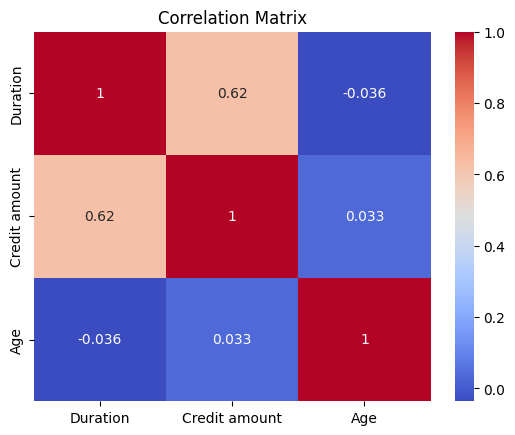

In [19]:
corr = X_features[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [19]:
# Loop through all combinations
for num_col in numerical_cols:
    for cat_col in categorical_cols:
        fig = px.histogram(
            df_plot,
            x=num_col,
            color='Creditability',
            facet_col=cat_col,
            marginal='box',
            nbins=50,
            title=f'{num_col} Distribution by {cat_col} and Creditability',
            labels={num_col: num_col, 'Creditability': ' (1: Good, 2: Bad)'}
        )
        fig.update_layout(
            xaxis_title=num_col,
            yaxis_title='Count',
            height=500,
            bargap=0.1
        )
        fig.show()

In [20]:
#gender based analysis
features_to_analyze = [
    'checking_status_string',
    'credit_history_string',
    'purpose_string',
    'savings_string',
    'employment_string',
    'other_guarantors_string',
    'property_string',
    'other_installment_string',
    'housing_string',
    'job_string',
    'marital_status',
    'has_guarantor',
    'is_unemployed',
    'has_telephone',
    'is_foreign',
    'has_other_debts',
    'Duration',
    'Credit amount',
    'Age'
]

fig = px.histogram(
    df_plot,
    x='gender',
    color='Creditability',
    barmode='group',
    title='Distribution of Creditability by Gender',
    labels={'gender': 'Gender', 'Creditability': ' (1: Good, 2: Bad)'}
)
fig.update_layout(xaxis_title='Gender', yaxis_title='Count')
fig.show()

for col in features_to_analyze:
  fig = px.histogram(
      df_plot,
      x=col,
      color='Creditability',
      facet_col='gender',
      barmode='group',
      title=f'Distribution of {col.replace("_", " ").title()} by Creditability and Gender',
      labels={col: col.replace('_', ' ').title(), 'Creditability': ' (1: Good, 2: Bad)', 'gender': 'Gender'}
  )
  fig.update_layout(xaxis_title=col.replace('_', ' ').title(), yaxis_title='Count')
  fig.show()

In [21]:
import plotly.express as px

age_bins = [18, 25, 35, 45, 55, 65, 120]
age_labels = ['18–24', '25–34', '35–44', '45–54', '55–64', '65+']

df_plot['AgeGroup'] = pd.cut(df_plot['Age'], bins=age_bins, labels=age_labels, right=False)


fig = px.histogram(
    df_plot,
    x='AgeGroup',
    color='Creditability',
    barmode='group',
    title='<b>Creditability Distribution by Age Group</b>',
    labels={'AgeGroup': 'Age Group', 'Creditability': 'Creditability'},
    category_orders={'AgeGroup': age_labels}
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Count',
    bargap=0.2,
    template='plotly_white',
    legend_title_text='Creditability'
)
fig.show()

# -------------------------------

features_to_analyze_age_groups = [
    'checking_status_string', 'credit_history_string', 'purpose_string', 'savings_string',
    'employment_string', 'other_guarantors_string', 'property_string', 'other_installment_string',
    'housing_string', 'job_string', 'marital_status', 'gender', 'has_guarantor', 'is_unemployed',
    'has_telephone', 'is_foreign', 'has_other_debts', 'Duration', 'Credit amount'
]

for col in features_to_analyze_age_groups:
    fig = px.histogram(
        df_plot,
        x=col,
        color='Creditability',
        facet_col='AgeGroup',
        barmode='group',
        title=f'<b>Distribution of {col.replace("_", " ").title()} by Creditability and Age Group</b>',
        labels={
            col: col.replace('_', ' ').title(),
            'Creditability': 'Creditability',
            'AgeGroup': 'Age Group'
        },
        category_orders={'AgeGroup': age_labels}
    )

    fig.update_layout(
        xaxis_title=col.replace('_', ' ').title(),
        yaxis_title='Count',
        bargap=0.15,
        template='plotly_white',
        legend_title_text='Creditability'
    )
    fig.for_each_annotation(lambda a: a.update(text=a.text.replace("AgeGroup=", "")))  # Clean facet labels
    fig.show()


In [21]:
#make new features
X_features['CreditPerMonth'] = X_features['Credit amount'] / X_features['Duration']
X_features['DebtLoad'] = X_features['Credit amount'] / (X_features['Installment rate in percentage of disposable income'] + 1)




In [22]:
from sklearn.model_selection import train_test_split

# Step 0: Combine your numeric and clean categorical features
final_categorical_features = [
    'checking_status_string', 'credit_history_string', 'purpose_string', 'savings_string', 'employment_string',
    'other_guarantors_string', 'property_string', 'other_installment_string', 'housing_string', 'job_string',
    'gender', 'marital_status', 'has_guarantor', 'is_unemployed', 'has_telephone', 'is_foreign', 'has_other_debts'
]

final_numerical_features = [
    'Duration', 'Credit amount', 'Installment rate in percentage of disposable income',
    'Present residence since', 'Age', 'Number of existing credits at this bank',
    'Number of people being liable to provide maintenance for', 'CreditPerMonth', 'DebtLoad'
]

selected_features = final_numerical_features + final_categorical_features
X = X_features[selected_features]
y_encoded = y['class'].map({1: 1, 2: 0})

X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

# Optional: Convert y back to DataFrame format for compatibility
y_train_encoded = y_train.to_frame()['class']
y_test_encoded = y_test.to_frame()['class']


In [23]:
categorical_cols = [col for col in final_categorical_features if col in X_train.columns]
numerical_cols = [col for col in X_train.columns if col not in categorical_cols]

X_cat_encoded = pd.get_dummies(X_train[categorical_cols], drop_first=True)

X_train_combined = pd.concat([X_train[numerical_cols], X_cat_encoded], axis=1)
X_test_cat_encoded = pd.get_dummies(X_test[categorical_cols], drop_first=True)

X_test_cat_encoded = X_test_cat_encoded.reindex(columns=X_cat_encoded.columns, fill_value=0)

X_train_combined.columns = (
    X_train_combined.columns
    .str.replace(r"[<>\[\]]", "", regex=True)
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

X_test_combined = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    X_test_cat_encoded.reset_index(drop=True)
], axis=1)


X_test_combined.columns = (
    X_test_combined.columns
    .str.replace(r"[<>\[\]]", "", regex=True)
    .str.replace(" ", "_")
    .str.replace("/", "_")
)



In [26]:
xgb_model = XGBClassifier(
    scale_pos_weight=sum(y_train_encoded == 0) / sum(y_train_encoded == 1),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=50,

    # Your best-found hyperparameters:
    subsample=1.0,
    reg_lambda=1,
    reg_alpha=1,
    n_estimators=200,
    max_depth=7,
    learning_rate=0.2,
    gamma=0,
    colsample_bytree=0.6
)

xgb_model.fit(X_train_combined, y_train_encoded)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:00:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=50, ...)

In [32]:
kf = KFold(n_splits=5, shuffle=True, random_state=101)

# 5. Run 5-Fold Cross Validation
cv_scores_5fold = cross_val_score(
    xgb_model,
    X_train_combined,
    y_train_encoded.values.ravel(),
    cv=kf
)

# 6. Print results
print("5-Fold Cross-Validation Scores:", cv_scores_5fold)
print("Average 5-Fold CV Score:", cv_scores_5fold.mean())


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:03:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:03:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:03:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:03:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




5-Fold Cross-Validation Scores: [0.75  0.725 0.75  0.675 0.75 ]
Average 5-Fold CV Score: 0.7300000000000001


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[08:03:48] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




In [33]:

y_pred = xgb_model.predict(X_test_combined)
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.53      0.48        60
           1       0.78      0.71      0.75       140

    accuracy                           0.66       200
   macro avg       0.61      0.62      0.62       200
weighted avg       0.68      0.66      0.67       200



In [38]:


# 4. Define model and CV strategy
rf_5fold = RandomForestClassifier(random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 5. Run 5-Fold Cross Validation
cv_scores_5fold = cross_val_score(
    rf_5fold,
    X_train_combined,
    y_train_encoded.values.ravel(),
    cv=kf
)

# 6. Print results
print("5-Fold Cross-Validation Scores:", cv_scores_5fold)
print("Average 5-Fold CV Score:", cv_scores_5fold.mean())


5-Fold Cross-Validation Scores: [0.775   0.775   0.7625  0.73125 0.725  ]
Average 5-Fold CV Score: 0.75375


In [41]:
rf_5fold.fit(X_train_combined, y_train_encoded)

y_pred = rf_5fold.predict(X_test_combined)
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.43      0.54        60
           1       0.79      0.92      0.85       140

    accuracy                           0.78       200
   macro avg       0.75      0.68      0.69       200
weighted avg       0.76      0.78      0.76       200



In [70]:

import numpy as np


# Compute class weight to handle imbalance
scale_pos_weight = sum(y_train_encoded == 0) / sum(y_train_encoded == 1)

# Define base model
xgb = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Define parameter grid (tune these as needed)
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 1, 5],
    'reg_lambda': [0, 1, 10],
    'reg_alpha': [0, 0.5, 1]
}

# Set up cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Define randomized search
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=30,  # You can increase for better results
    scoring=make_scorer(f1_score),
    n_jobs=-1,
    cv=kf,
    verbose=1,
    random_state=42
)

# Run optimization
random_search.fit(X_train_combined, y_train_encoded)

# Output best results
print("Best Parameters:", random_search.best_params_)
print("Best F1 Score:", random_search.best_score_)


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.6}
Best F1 Score: 0.8238928265728049


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:50:19] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:49:41] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




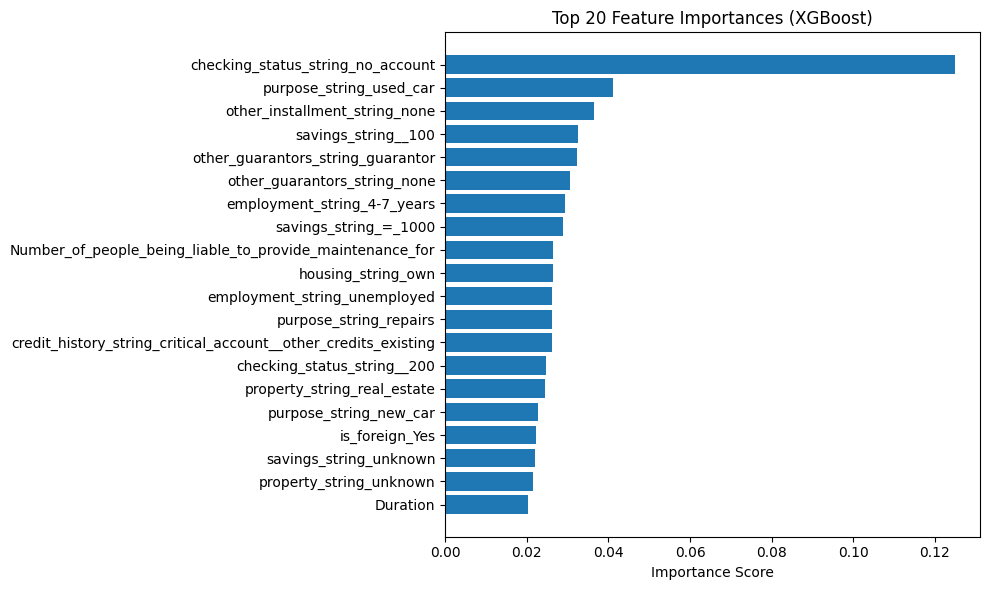

In [68]:
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score

# Step 1: Fit XGBoost Model
model_fs = XGBClassifier(
    scale_pos_weight=sum(y_train_encoded == 0) / sum(y_train_encoded == 1),
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=50
)
model_fs.fit(X_train_combined, y_train_encoded)

# Step 2: Get feature importances
importances = model_fs.feature_importances_
feature_names = X_train_combined.columns
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Optional: plot top 20
plt.figure(figsize=(10, 6))
plt.barh(feat_imp_df['Feature'][:20][::-1], feat_imp_df['Importance'][:20][::-1])
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [65]:
# from sklearn.ensemble import StackingClassifier
# from sklearn.linear_model import LogisticRegression
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
# from sklearn.model_selection import cross_val_score, KFold
# from sklearn.metrics import f1_score, classification_report
# # Base models
# X_train_combined.columns = (
#     X_train_combined.columns
#     .str.replace(r"[<>\[\]]", "", regex=True)
#     .str.replace(" ", "_")
#     .str.replace("/", "_")
# )

# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler

# # Wrap Logistic Regression with scaling
# meta_learner = make_pipeline(StandardScaler(), LogisticRegression(max_iter=10000))

# from imblearn.over_sampling import SMOTE
# sm = SMOTE(random_state=42)
# X_resampled, y_resampled = sm.fit_resample(X_train_combined, y_train_encoded)


# base_learners = [
#     ('xgb', XGBClassifier(
#         use_label_encoder=False,
#         eval_metric='logloss',
#         scale_pos_weight=sum(y_train_encoded == 0) / sum(y_train_encoded == 1),
#         random_state=15
#     ))
# ]

# # Meta-learner
# # meta_learner = LogisticRegression()
# stacking_clf = StackingClassifier(
#     estimators=base_learners,
#     final_estimator=meta_learner,
#     cv=5,
#     n_jobs=-1,
#     passthrough=True  # You can set True if you want to feed original features to meta-model as well
# )

# stacking_clf.fit(X_resampled, y_resampled)



# # Evaluation
# y_pred = stacking_clf.predict(X_train_combined)
# print("Classification Report:\n", classification_report(y_train_encoded, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.72      0.77       240
           1       0.89      0.94      0.91       560

    accuracy                           0.87       800
   macro avg       0.86      0.83      0.84       800
weighted avg       0.87      0.87      0.87       800



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning:

[14:53:02] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=0, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=50, ...)

In [72]:
# Encode test categorical features
X_test_cat_encoded = pd.get_dummies(X_test[categorical_cols], drop_first=True)

# Align test encoded columns with train encoded columns
X_test_cat_encoded = X_test_cat_encoded.reindex(columns=X_cat_encoded.columns, fill_value=0)

# Combine test numerical and encoded categorical features (with index reset to avoid NaNs)
X_test_combined = pd.concat([
    X_test[numerical_cols].reset_index(drop=True),
    X_test_cat_encoded.reset_index(drop=True)
], axis=1)


X_test_combined.columns = (
    X_test_combined.columns
    .str.replace(r"[<>\[\]]", "", regex=True)
    .str.replace(" ", "_")
    .str.replace("/", "_")
)

# Predict
y_pred = model_fs.predict(X_test_combined)
print("Classification Report:\n", classification_report(y_test_encoded, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.48      0.52      0.50        60
           1       0.79      0.76      0.78       140

    accuracy                           0.69       200
   macro avg       0.64      0.64      0.64       200
weighted avg       0.70      0.69      0.69       200



In [43]:
joblib.dump(rf_5fold, 'credit_model_rf.joblib')


['credit_model_rf.joblib']

In [42]:
joblib.dump(list(X_train_combined.columns), "feature_list.joblib")
joblib.dump(rf_5fold, "credit_model_rf.joblib")

['credit_model_rf.joblib']

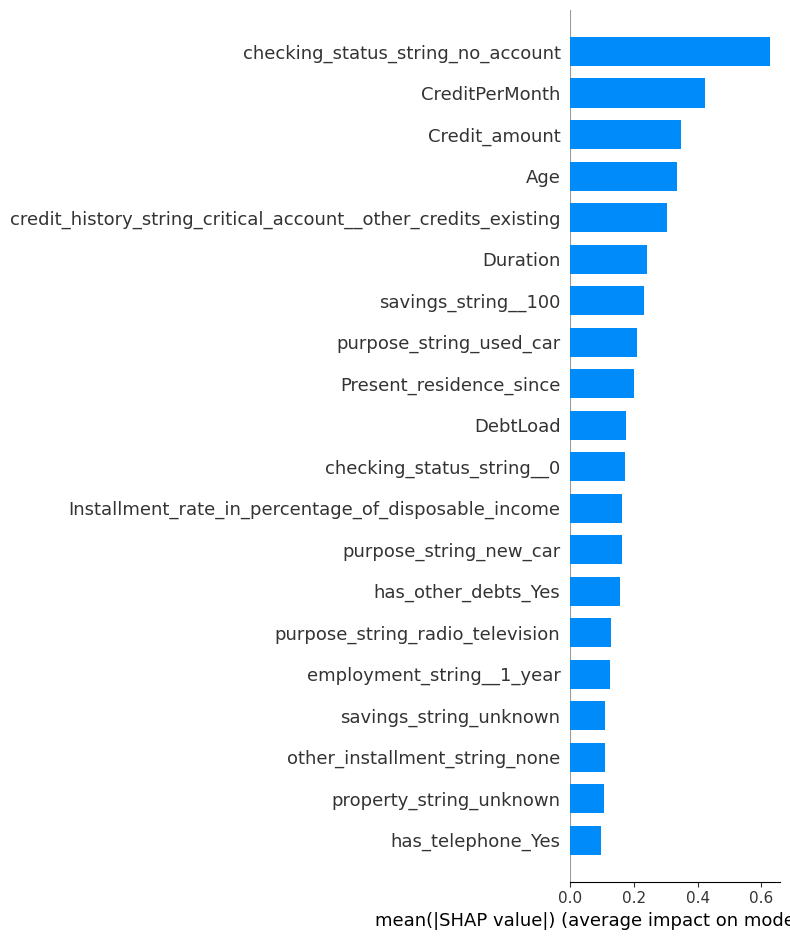

In [44]:
import shap
X_train_combined = X_train_combined.astype('float64')
X_test_combined = X_test_combined.astype('float64')

explainer = shap.Explainer(xgb_model, X_train_combined)
shap_values = explainer(X_test_combined)

# Global feature importance (bar plot)
shap.summary_plot(shap_values, X_test_combined, plot_type='bar')



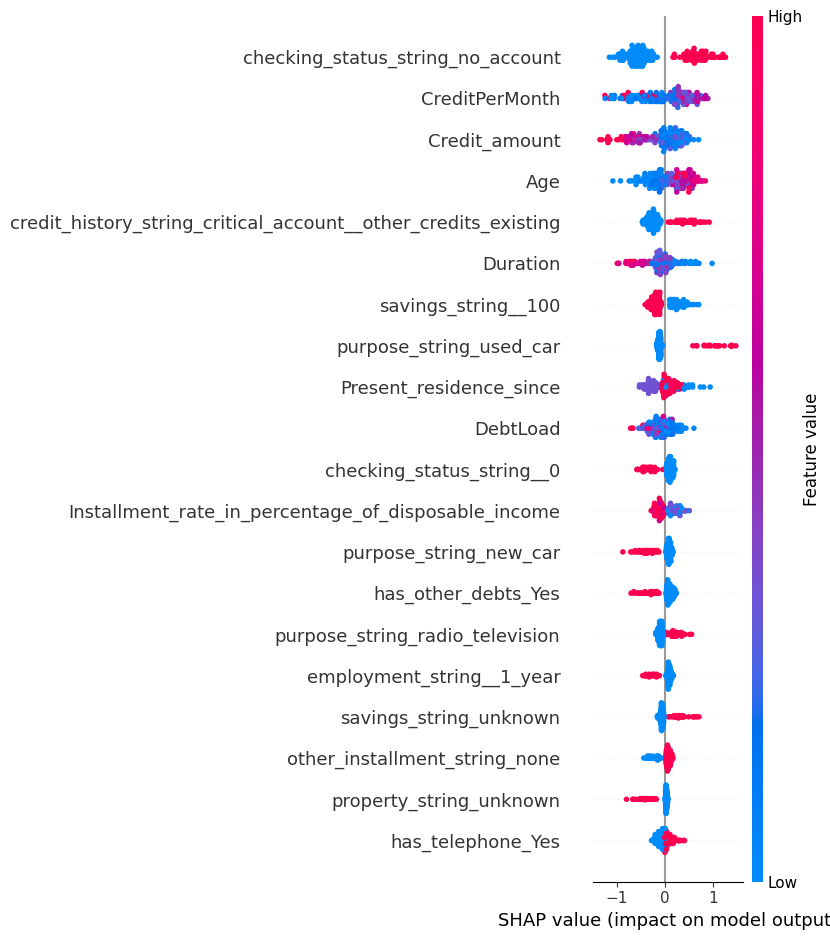

In [45]:
shap.summary_plot(shap_values, X_test_combined)


In [ ]:

# Local explanation for the first test sample
shap.plots.waterfall(shap_values[0])

In [50]:
X_test_sensitive = X_test_combined[['gender_male', 'is_foreign_Yes', 'has_guarantor_Yes', 'marital_status_single', 'has_other_debts_Yes']].copy()

# Combine predictions and true labels with sensitive features
df_test = pd.DataFrame({
    'y_true': y_test_encoded.values.ravel(),
    'y_pred': y_pred
}, index=X_test_combined.index)

df_test = pd.concat([df_test, X_test_sensitive], axis=1)

# Group-by F1-score by each sensitive attribute
for col in ['gender_male', 'is_foreign_Yes', 'has_guarantor_Yes', 'marital_status_single', 'has_other_debts_Yes']:
    print(f"\n Performance by {col}:")
    for group in df_test[col].unique():
        mask = df_test[col] == group
        score = f1_score(df_test['y_true'][mask], df_test['y_pred'][mask])
        print(f"  {group}: F1 = {score:.3f}")


 Performance by gender_male:
  1.0: F1 = 0.861
  0.0: F1 = 0.828

 Performance by is_foreign_Yes:
  1.0: F1 = 0.843
  0.0: F1 = 1.000

 Performance by has_guarantor_Yes:
  0.0: F1 = 0.853
  1.0: F1 = 0.833

 Performance by marital_status_single:
  1.0: F1 = 0.876
  0.0: F1 = 0.816

 Performance by has_other_debts_Yes:
  0.0: F1 = 0.857
  1.0: F1 = 0.828


In [51]:
# Group-wise positive prediction rate for each sensitive attribute
sensitive_features_list = ['gender_male', 'is_foreign_Yes', 'has_guarantor_Yes', 'marital_status_single', 'has_other_debts_Yes']

for col in sensitive_features_list:
    pos_rate = df_test.groupby(col)['y_pred'].mean()
    print(f"\n Positive prediction rates by {col}:")
    print(pos_rate)
    if len(pos_rate) > 1:
        print(f"Disparity Ratio (max/min): {pos_rate.max() / pos_rate.min():.2f}")
    else:
        print("Disparity Ratio: N/A (only one group)")


 Positive prediction rates by gender_male:
gender_male
0.0    0.783333
1.0    0.828571
Name: y_pred, dtype: float64
Disparity Ratio (max/min): 1.06

 Positive prediction rates by is_foreign_Yes:
is_foreign_Yes
0.0    0.888889
1.0    0.811518
Name: y_pred, dtype: float64
Disparity Ratio (max/min): 1.10

 Positive prediction rates by has_guarantor_Yes:
has_guarantor_Yes
0.0    0.815217
1.0    0.812500
Name: y_pred, dtype: float64
Disparity Ratio (max/min): 1.00

 Positive prediction rates by marital_status_single:
marital_status_single
0.0    0.784091
1.0    0.839286
Name: y_pred, dtype: float64
Disparity Ratio (max/min): 1.07

 Positive prediction rates by has_other_debts_Yes:
has_other_debts_Yes
0.0    0.823899
1.0    0.780488
Name: y_pred, dtype: float64
Disparity Ratio (max/min): 1.06


In [48]:
!pip install fairlearn



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 14.4 MB/s eta 0:00:00


In [52]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import accuracy_score

# Define the sensitive features to include in the MetricFrame
sensitive_features_for_fairlearn = df_test[['gender_male', 'is_foreign_Yes', 'has_guarantor_Yes', 'marital_status_single', 'has_other_debts_Yes']]

metric_frame = MetricFrame(
    metrics={
        'accuracy': accuracy_score,
        'selection_rate': selection_rate
    },
    y_true=df_test['y_true'],
    y_pred=df_test['y_pred'],
    sensitive_features=sensitive_features_for_fairlearn
)

print(metric_frame.by_group)

                                                                                        accuracy  \
gender_male is_foreign_Yes has_guarantor_Yes marital_status_single has_other_debts_Yes             
0.0         0.0            0.0               0.0                   0.0                       NaN   
                                                                   1.0                       NaN   
                                             1.0                   0.0                       NaN   
                                                                   1.0                       NaN   
                           1.0               0.0                   0.0                       NaN   
                                                                   1.0                       NaN   
                                             1.0                   0.0                       NaN   
                                                                   1.0                       NaN   
